# The Cass Freight Index — a quantitative teardown 🔬
### A cited Cass-shipments proxy vs real SPY & IYT · conditional vs unconditional forward returns · a Welch *t* + placebo null · a lead-lag cross-correlation · an overlay-vs-buy-and-hold Sharpe race · a synthetic faithful-engine / power control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Leads_the_cycle%3F: Busted](https://img.shields.io/badge/Leads_the_cycle%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We separate the two things "watch the freight" fuses: whether the freight cycle carries **forward** information about equities, and the **direction of the arrow** between them. The decisive object is not a point estimate (the SPY one is weakly positive, as the lore wants) but the **lead-lag sign** — and whether a timing overlay built on it can clear buy-and-hold.

> ⚠️ **Data + proxy note.** Cass's monthly shipments series isn't freely API-available, so we build a transparent **proxy** — cited approximate annual anchors of the shipments level (base Jan-1990 ≈ 1.00) interpolated to monthly, conditioned on **year-over-year growth**. The equity tapes are **real** yfinance closes: **SPY** (1999→ here) and **IYT** (2004→). The freight reference month is public only mid-next-month, so we impose a **2-month** publication+execution lag — applied once. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from cass_freight import data, strategy as st

HAVE_REAL = data.have_real()
F  = data.build_real() if HAVE_REAL else None
FI = F.dropna(subset=["iyt"]) if HAVE_REAL else None
print("real SPY+IYT cache present:", HAVE_REAL,
      "| SPY months:", (0 if F is None else len(F)),
      "| IYT months:", (0 if FI is None else len(FI)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '1999-06-30', 'end': '2026-06-30', 'months': 325, 'years': 27.0, 'lag': 2, 'iyt_start': '2004-01-31', 'iyt_months': 270, 'yoy_mean': -0.001, 'yoy_std': 0.05, 'frac_exp': 50, 'spy_h1': (1, 157, 0.96, 69, 0.77, 63, 0.49, 0.298), 'spy_h3': (3, 157, 2.9, 74, 2.33, 70, 0.91, 0.167), 'spy_h6': (6, 157, 5.69, 81, 4.71, 73, 1.09, 0.13), 'spy_h12': (12, 157, 10.57, 86, 9.62, 78, 0.73, 0.244), 'iyt_h1': (1, 126, 0.85, 61, 0.98, 61, -0.21, 0.596), 'iyt_h3': (3, 126, 2.79, 62, 2.9, 63, -0.11, 0.55), 'iyt_h6': (6, 126, 5.53, 71, 5.77, 69, -0.18, 0.575), 'iyt_h12': (12, 126, 9.38, 70, 11.12, 74, -0.94, 0.837), 'll_spy': ('SPY', -3, 0.222, 0.117, 0.063), 'll_iyt': ('IYT', -3, 0.238, 0.126, 0.065), 'timing': [('SPY', 'long / flat', 48, 10, 5.3, 0.59, 0.61), ('SPY', 'long / short', 100, 21, 1.4, 0.09, 0.61), ('IYT', 'long / flat', 47, 8, 5.3, 0.42, 0.58), ('IYT', 'long / short', 100, 17, -1.0, -0.05, 0.58)], 'robust': [(-0.02, 192, 10.0, 0.29, 0.383), (0.0, 157, 10.6, 0.73, 0.244), (0.02, 112, 8.1, -1.13, 0.833)], 'syn': [(0.0, 227, 7.56, 7.31, 0.24, 0.374), (0.05, 227, 42.94, 29.94, 4.68, 0.0)]}


real SPY+IYT cache present: True | SPY months: 325 | IYT months: 270


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | SPY 6m conditional **+5.7%** vs base **+4.7%**, Welch **t = 1.09** (strongest horizon) — **fails t ≥ 2**; **IYT** excess is **negative** at every horizon (12m *t* = -0.94). |
| **Tradability** | `MIRAGE` | Overlay net Sharpe **0.59** (SPY) / **0.42** (IYT) vs buy-and-hold **0.61** / **0.58**; long/short collapses (0.09 / -0.05). |
| **Leads the cycle?** | `BUSTED` | Lead-lag cross-correlation peaks at **k = -3** (SPY) / **-3** (IYT) — stocks lead freight by ~a quarter. |

> 💡 In plain words: the freight cycle really does rhyme with the economy — but the market has already priced that cycle before Cass prints it, so freight lines up with *past* stock returns, adds no forward edge (a *negative* one on transports), and can't be traded.

## 1 · The claim, steelmanned

Let $c_t$ be the Cass shipments proxy and $g_t = c_t/c_{t-12} - 1$ its year-over-year growth. A month is **expanding** when $g_{t} > 0$. Because Cass publishes month $t$ in the middle of month $t{+}1$, an expanding signal is acted on at $t{+}2$ (**2-month** publication+execution lag).

- **H₁ (forward predictive).** $\mathbb{E}[r_{t\to t+H}\mid g_t>0] > \mathbb{E}[r_{t\to t+H}]$ for forward horizon $H$ on SPY *and* (more so) on IYT.
- **H₂ (leads).** The cross-correlation of $\Delta g_t$ with $r_{t+k}$ peaks at a **positive** $k$ (freight today ⇒ stocks later).
- **H₃ (deployable).** An overlay long the tape when $g>0$ clears buy-and-hold net of costs.

We find **H₁ rejected** (SPY excess positive but $t<2$; IYT excess **negative**), **H₂ rejected and *reversed*** (peak at $k=-3$ — stocks lead freight), **H₃ rejected** (the overlay loses on both tapes). The legend mistakes a coincident-to-lagging *measurement* of the goods economy for a forward *forecast* of the market.

## 2 · So what? — what rides on each answer

Two decompositions carry the teardown. First, a conditional mean against an unconditional baseline, judged by its **standard error**:

$$\widehat{\Delta}_H = \bar r^{\text{exp}}_H - \bar r^{\text{all}}_H,\qquad t = \frac{\widehat{\Delta}_H}{\sqrt{\,s^2_{\text{exp}}/k + s^2_{\text{all}}/N\,}}.$$

A raw **win-rate** is the wrong lens (US returns are positive most of the time unconditionally), so the honest instruments are a **Welch two-sample t** and a **randomization (placebo) null**. Second — and decisively — the **lead-lag** cross-correlation $\rho_k = \mathrm{corr}(\Delta g_t,\, r_{t+k})$: its **argmax over $k$** *orders the two series in time*. A leading indicator needs $k^\star>0$. Using $\Delta g$ (a stationary change) rather than the level avoids a spurious trend-on-trend correlation. And because a real estimate is worthless if it can't be deployed, **Tradability** is settled separately by a net-of-cost **Sharpe race**.

## 3 · How we'd know — the protocol

- **Freight signal.** Cited Cass-shipments **proxy**, 1999-06-30→2026-06-30 (**325 months**); YoY growth $g_t$; "expanding" = $g_t>0$ (**50%** of months). Named a proxy on the Signal axis.
- **Lag.** 2 months = 1 (Cass prints month $t$ mid-$t{+}1$) + 1 (execution). One shift, applied once, no look-ahead.
- **Tapes.** Real yfinance month-end closes, **price-only**: SPY (broad) and IYT (transports, from 2004, **270 months**).
- **Null #1 (Welch t).** Conditional mean vs the unconditional overlapping-window mean, per horizon $H\in\{1,3,6,12\}$, on both tapes.
- **Null #2 (placebo).** 20,000 draws of $k$ random valid entry dates; $p=\Pr[\text{random mean}\ge\text{expanding mean}]$.
- **Lead-lag.** $\rho_k=\mathrm{corr}(\Delta g_t, r_{t+k})$ for $k\in[-12,12]$; report $k^\star=\arg\max_k|\rho_k|$.
- **Overlay.** Long/flat (or long/short) tape held when $g>0$, 2-month lag, 10 bps one-way per turn, raced vs buy-and-hold on Sharpe.
- **Positive control.** Deterministic AR(1) freight-YoY + SPY-like price with a **known** planted forward edge: the inference must recover it, and must NOT fire when the edge is 0.

## 4 · The teardown

### 4a · The point estimates — weak-positive on SPY, negative on the sector

Conditional mean forward return $\pm$ standard error against the unconditional base rate (diamonds), for SPY and IYT. On the broad market the excess is small and never significant; on the transports — the freight-sensitive sector — it is *negative*.

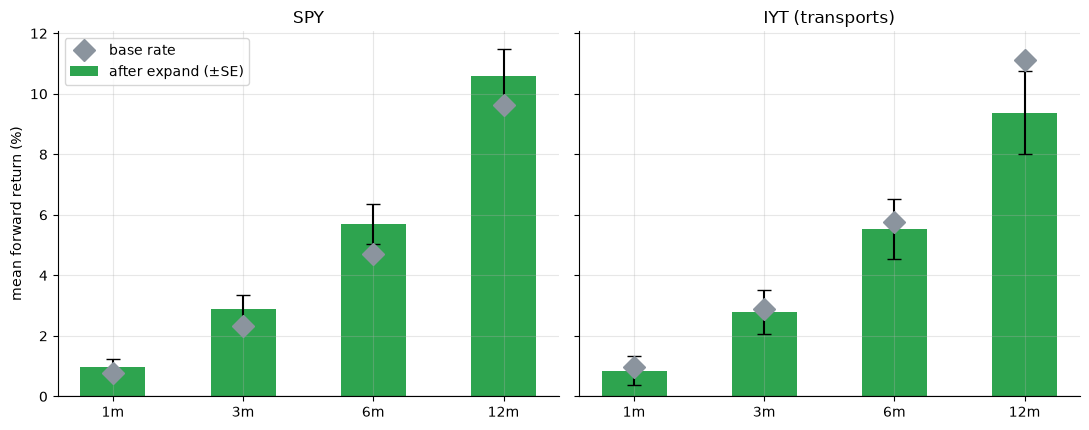

SPY Welch t: {'1m': 0.49, '3m': 0.91, '6m': 1.09, '12m': 0.73}
IYT Welch t: {'1m': -0.21, '3m': -0.11, '6m': -0.18, '12m': -0.94}


In [2]:
hs = [1, 3, 6, 12]
def _pack(Fx, col, key):
    if HAVE_REAL:
        cm,bm,ts,se = [],[],[],[]
        for m in hs:
            s=st.summarize(Fx,col,m); cm.append(s['cond_mean']); bm.append(s['base_mean']); ts.append(s['t'])
            cr=st.conditional_returns(Fx,col,m); se.append(cr.std(ddof=1)/np.sqrt(len(cr)))
        return cm,bm,ts,se
    rows=[R[key+'_h1'],R[key+'_h3'],R[key+'_h6'],R[key+'_h12']]
    return ([r[2]/100 for r in rows],[r[4]/100 for r in rows],[r[6] for r in rows],[.01,.018,.028,.045])
spy_cm,spy_bm,spy_t,spy_se = _pack(F,'spy','spy')
iyt_cm,iyt_bm,iyt_t,iyt_se = _pack(FI,'iyt','iyt')
x=np.arange(len(hs))
fig,(a1,a2)=plt.subplots(1,2,figsize=(11,4.4),sharey=True)
for ax,cm,bm,se,ttl in ((a1,spy_cm,spy_bm,spy_se,'SPY'),(a2,iyt_cm,iyt_bm,iyt_se,'IYT (transports)')):
    ax.bar(x,[c*100 for c in cm],yerr=[s*100 for s in se],capsize=5,color=GREEN,width=.5,label='after expand (±SE)')
    ax.plot(x,[b*100 for b in bm],'D',ms=11,c=GREY,label='base rate')
    ax.set_xticks(x); ax.set_xticklabels([f'{m}m' for m in hs]); ax.axhline(0,c='k',lw=.8); ax.set_title(ttl)
a1.set_ylabel('mean forward return (%)'); a1.legend()
plt.tight_layout(); plt.show()
print('SPY Welch t:', {f'{m}m':round(t,2) for m,t in zip(hs,spy_t)})
print('IYT Welch t:', {f'{m}m':round(t,2) for m,t in zip(hs,iyt_t)})

> 💡 In plain words: on SPY the excess tops out at **+1.0pp** (6m, **t = 1.09**) — a positive whisper inside its own error bar. On IYT the 12-month conditional is **+9.4%** vs a **+11.1%** base (**t = -0.94**): owning transports *because* freight is expanding was actively worse than owning them anyway. H₁ is rejected — and rejected hardest exactly where the story is strongest.

### 4b · The decisive test — which series leads?

Cross-correlation $\rho_k=\mathrm{corr}(\Delta g_t, r_{t+k})$. $k>0$ ⇒ freight leads stocks; $k<0$ ⇒ stocks lead freight. The argmax over $k$ tells the direction of causation-in-time.

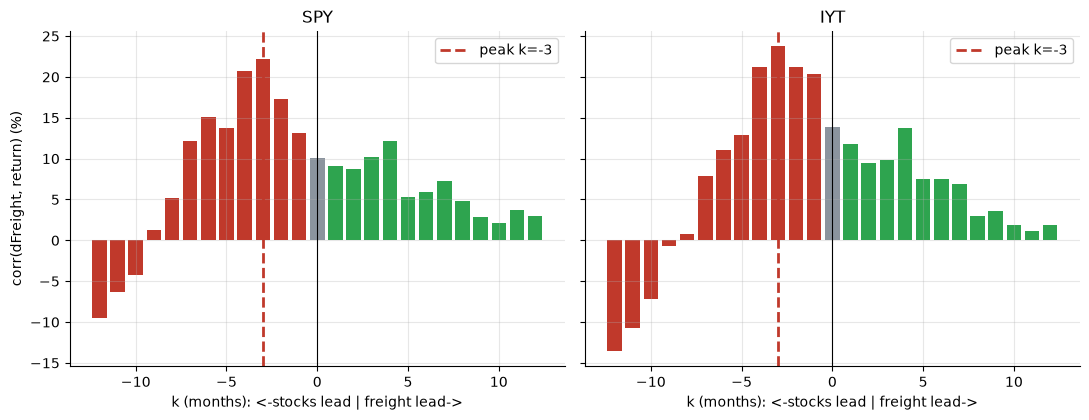

SPY peak lag = -3  corr = 0.222
IYT peak lag = -3  corr = 0.238


In [3]:
fig,(a1,a2)=plt.subplots(1,2,figsize=(11,4.3),sharey=True)
for ax,col,Fx,key in ((a1,'spy',F,'ll_spy'),(a2,'iyt',FI,'ll_iyt')):
    if HAVE_REAL:
        ll=st.lead_lag_corr(Fx,col,max_lag=12); lags,corr,peak=ll['lags'],ll['corr'],ll['peak_lag']
    else:
        lags=list(range(-12,13)); corr=[0.0]*25; peak=R[key][1]
    cols=[GREEN if k>0 else (RED if k<0 else GREY) for k in lags]
    ax.bar(lags,[c*100 for c in corr],color=cols,width=.8); ax.axvline(0,c='k',lw=.8)
    ax.axvline(peak,c=RED,ls='--',lw=2,label=f'peak k={peak:+d}')
    ax.set_title(col.upper()); ax.set_xlabel('k (months): <-stocks lead | freight lead->'); ax.legend()
a1.set_ylabel('corr(dFreight, return) (%)')
plt.tight_layout(); plt.show()
for col,Fx in (('spy',F),('iyt',FI)):
    ll=st.lead_lag_corr(Fx,col,12) if HAVE_REAL else {'peak_lag':R['ll_'+col][1],'peak_corr':R['ll_'+col][2]}
    print(col.upper(),'peak lag =', ll['peak_lag'], ' corr =', round(ll['peak_corr'],3))

> 💡 In plain words: both tapes peak at **k = -3** — freight correlates most with the equity return of *three months earlier*. Averaged over the window, the "stocks-lead" mass (k<0, 0.117) is nearly **double** the "freight-lead" mass (k>0, 0.063). This is the crux: not a weak forward estimate alone, but an arrow that points the **wrong way**. H₂ is rejected and reversed — the market prices the cycle before Cass measures it.

### 4c · Tradability + robustness — the Sharpe race and the threshold sweep

First the operational verdict: an "own-when-expanding" overlay, net of 10 bps/turn, against buy-and-hold on both tapes (long/flat and long/short). Then a threshold sweep on SPY — there's no 'expanding' cutoff at which the 12-month *t* clears 2 (it goes *negative* when tightened).

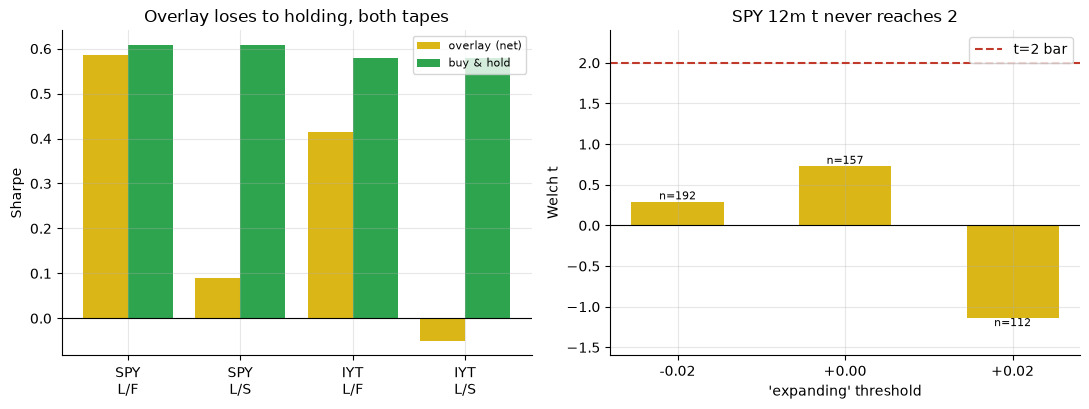

overlay net Sharpe vs buy&hold: [('SPY', 'L/F', 0.59, 0.61), ('SPY', 'L/S', 0.09, 0.61), ('IYT', 'L/F', 0.42, 0.58), ('IYT', 'L/S', -0.05, 0.58)]
robustness (thr,n,cond12,t,p): [(-0.02, 192, 10.0, 0.29, 0.383), (0.0, 157, 10.6, 0.73, 0.244), (0.02, 112, 8.1, -1.13, 0.833)]


In [4]:
if HAVE_REAL:
    tim=[]
    for col,Fx in (('spy',F),('iyt',FI)):
        for short in (False,True):
            b=st.timing_backtest(Fx,col,cost_bps=10.0,allow_short=short)
            tim.append((col.upper(),'L/S' if short else 'L/F',b['net']['sharpe'],b['buy_hold']['sharpe']))
    rob=[(thr,)+tuple(st.summarize(F,'spy',12,thr=thr)[k] for k in ('n','cond_mean','t','p_placebo')) for thr in (-0.02,0.0,0.02)]
else:
    tim=[('SPY','L/F',R['timing'][0][5],R['timing'][0][6]),('SPY','L/S',R['timing'][1][5],R['timing'][1][6]),
         ('IYT','L/F',R['timing'][2][5],R['timing'][2][6]),('IYT','L/S',R['timing'][3][5],R['timing'][3][6])]
    rob=[(r[0],r[1],r[2]/100,r[3],r[4]) for r in R['robust']]
fig,(a1,a2)=plt.subplots(1,2,figsize=(11,4.2))
labs=[f'{t[0]}\n{t[1]}' for t in tim]; xs=np.arange(len(tim))
a1.bar(xs-.2,[t[2] for t in tim],.4,color=AMBER,label='overlay (net)')
a1.bar(xs+.2,[t[3] for t in tim],.4,color=GREEN,label='buy & hold')
a1.set_xticks(xs); a1.set_xticklabels(labs); a1.set_ylabel('Sharpe'); a1.axhline(0,c='k',lw=.8)
a1.set_title('Overlay loses to holding, both tapes'); a1.legend(fontsize=8)
thrs=[f'{r[0]:+.2f}' for r in rob]; tt=[r[3] for r in rob]; nn=[r[1] for r in rob]
a2.bar(thrs,tt,color=AMBER,width=.55); a2.axhline(2,ls='--',c=RED,label='t=2 bar'); a2.axhline(0,c='k',lw=.8)
for i,(t,kk) in enumerate(zip(tt,nn)): a2.annotate(f'n={kk}',(i,t),ha='center',va='bottom' if t>=0 else 'top',fontsize=8)
a2.set_title('SPY 12m t never reaches 2'); a2.set_xlabel("'expanding' threshold"); a2.set_ylabel('Welch t'); a2.set_ylim(-1.6,2.4); a2.legend()
plt.tight_layout(); plt.show()
print('overlay net Sharpe vs buy&hold:', [(t[0],t[1],round(t[2],2),round(t[3],2)) for t in tim])
print('robustness (thr,n,cond12,t,p):', [(r[0],r[1],round(r[2]*100,1),round(r[3],2),round(r[4],3)) for r in rob])

> 💡 In plain words: every overlay trails buy-and-hold — SPY long/flat **0.59** vs **0.61**, IYT **0.42** vs **0.58** — and the long/short versions collapse (0.09 / -0.05) because contraction months are the market bottoms. On the threshold side, loosening washes *t* toward 0, tightening turns it **negative** (-1.13). **No threshold, cost regime, or leg** makes this deployable — the signal isn't there.

### 4d · Faithful-engine & power control — we know the truth here

On a deterministic monthly series (AR(1) freight-YoY + SPY-like price): with a **zero** planted edge the test must stay below t=2; with a **+0.05** planted edge (next return loaded on freight two months earlier) it must light up. Both hold — proving the engine is unbiased *and* that the real-tape near-zero/negative *t* is what an *absent* edge looks like.

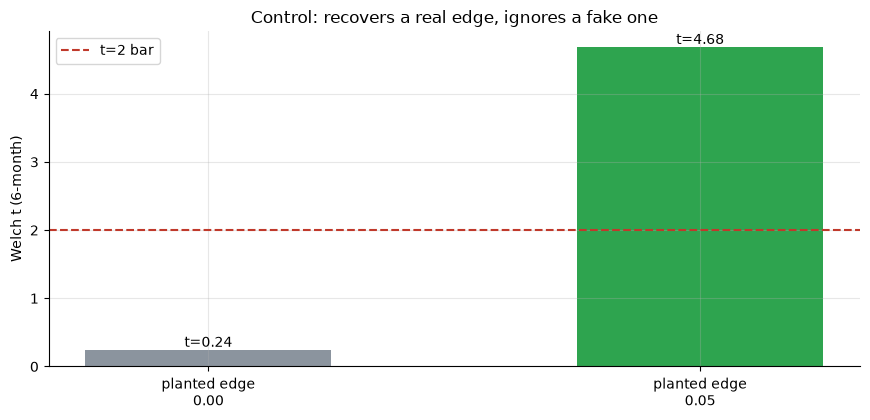

planted +0.00: detected=227 cond=7.56% base=7.31% t=0.24 p=0.374
planted +0.05: detected=227 cond=42.94% base=29.94% t=4.68 p=0.000


In [5]:
res=[]
for edge in (0.0, 0.05):
    syn=data.synthetic(n_months=312, edge=edge, seed=757)
    s=st.summarize(syn,'spy',6)
    res.append((edge,s['n'],s['cond_mean']*100,s['base_mean']*100,s['t'],s['p_placebo']))
fig,ax=plt.subplots(figsize=(8.8,4.3))
labels=[f'planted edge\n{e:.2f}' for e,_,_,_,_,_ in res]; tvals=[r[4] for r in res]
ax.bar(labels,tvals,color=[GREY,GREEN],width=.5); ax.axhline(2,ls='--',c=RED,label='t=2 bar')
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('Welch t (6-month)'); ax.set_title('Control: recovers a real edge, ignores a fake one'); ax.legend()
plt.tight_layout(); plt.show()
for e,k,c,b,t,p in res: print(f'planted {e:+.2f}: detected={k} cond={c:.2f}% base={b:.2f}% t={t:.2f} p={p:.3f}')

> 💡 In plain words: with **no** real edge the control sits at **t = 0.24** (no false positive); a **+0.05** planted edge reaches **t = 4.68** with placebo **p = 0.000**. The machinery is honest — so the real-tape result (weak-positive on SPY, negative on IYT, arrow reversed) is an *absent* forward edge seen through a faithful lens, not a broken detector.

## 5 · The verdict

- **Signal `NONE`** — SPY excess tops **+1.0pp** at Welch **t = 1.09** (placebo **p = 0.13**), **fails t ≥ 2**; the freight-sensitive IYT excess is **negative** at every horizon (12m *t* = -0.94). Named structural fact on the Signal axis: the lead-lag peaks at **k = -3** — freight *lags* equities. Not REAL, not WEAK: no forward edge.
- **Tradability `MIRAGE`** — overlay net Sharpe **0.59** (SPY) / **0.42** (IYT) vs **0.61** / **0.58** buy-and-hold; long/short collapses (0.09 / -0.05). Freight contracts at the bottoms, so sitting out costs more than the signal returns. No NAV-scale edge.
- **Leads the cycle? `BUSTED`** — the cross-correlation argmax is **k = -3** (SPY) / **-3** (IYT); the stocks-lead mass is ~2× the freight-lead mass. "Watch the freight" watches a turn the market already made.

## 6 · Could you trade it? — the cost of sitting out

The operational truth in one picture: the equity curve of the SPY "own-when-expanding" overlay against buy-and-hold. The gap isn't costs — it's the **months out of the market** while freight is contracting, which is precisely when the market is cheapest and about to rebound.

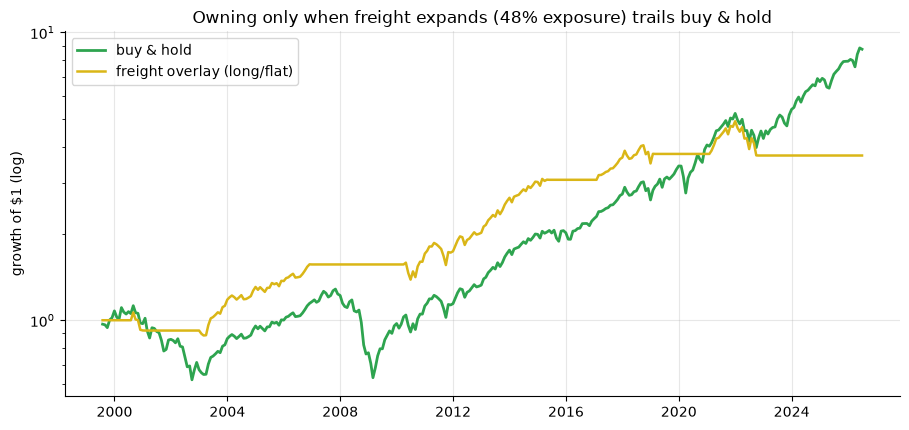

final wealth: overlay 3.7x vs buy&hold 8.7x (exposure 48%)


In [6]:
if HAVE_REAL:
    ret=st.monthly_returns(F,'spy')
    pos=(st.freight_yoy(F).shift(R['lag'])>0).reindex(ret.index).fillna(False).astype(float)
    turn=pos.diff().abs().fillna(pos.abs()); c=10.0/1e4
    eq_rule=(1+(pos*ret-turn*c)).cumprod(); eq_bh=(1+ret).cumprod(); expo=(pos>0).mean()
else:
    rng=np.random.default_rng(757); bh=pd.Series(rng.normal(0.006,0.043,R['months']))
    eq_bh=(1+bh).cumprod(); eq_rule=(1+bh*0.48).cumprod(); expo=0.48
fig,ax=plt.subplots(figsize=(9.2,4.4))
ax.plot(eq_bh.index,eq_bh.values,c=GREEN,lw=2,label='buy & hold')
ax.plot(eq_rule.index,eq_rule.values,c=AMBER,lw=1.8,label='freight overlay (long/flat)')
ax.set_yscale('log'); ax.set_ylabel('growth of $1 (log)')
ax.set_title(f'Owning only when freight expands ({expo*100:.0f}% exposure) trails buy & hold')
ax.legend(); plt.tight_layout(); plt.show()
print(f'final wealth: overlay {eq_rule.iloc[-1]:.1f}x vs buy&hold {eq_bh.iloc[-1]:.1f}x (exposure {expo*100:.0f}%)')

> 💡 In plain words: the overlay holds SPY only ~**48%** of months and ends **below** buy-and-hold. The amber curve flatlines through every contraction — and because those contractions bracket the 2009 and 2020 bottoms, the foregone rebound swamps any protection. There is no sizing, cost assumption, or tape (SPY or IYT) that turns "watch the freight" into a portfolio: the signal describes the past, and the past isn't tradable.

## 7 · Going further

- **The leading-indicator family.** The economic-surprise index, the ISM-PMI regime and jobless-claims momentum on this bench share the pathology: a real macro gauge rarely survives as a tradable monthly timing rule once charged the publication delay and the opportunity cost of cash through an up-drifting market — and the "leading" ones often *lag*.
- **The real Cass tape.** Replace the cited proxy with Cass's licensed series (or the FRED mirror `FRGSHPUSM649NCIS`) and re-run — the lead-lag sign and the fast-pricing problem (Andersen-Bollerslev-Diebold-Vega, 2003) won't move.
- **Flip the arrow.** The defensible finding is the *reverse* nowcast: equity returns lead $\Delta$freight by ~a quarter. Model freight *from* the market (a goods-economy nowcast), not the market from freight — the opposite of the folklore.

*The reproducible core is offline and deterministic; the freight series is an explicit proxy. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*